# Model

The model is a slab-atmosphere-model (SAM) and a slab-ocean-model (SOM). They only have one grid point each.


## Atmosphere

$ m_a c_{pa} \partial_t T_a = - \left( LW_{TOA} + SW_{TOA} - SW_{sfc} - LHF \right) $

## Ocean

$ d c_{po} \rho_{o} \partial_t T_o = - \left( SW_{sfc} + LHF \right) $

## Flux

- Longwave radiation flux at top-of-atmoshpere: $ LW_{TOA} = \sigma T_a^4 $
- Shortwave radiation flux at top-of-atmosphere: $ SW_{TOA}\left(t\right) = - \frac{S_0}{4} $
- Shortwave radiation flux at surface: $ SW_{sfc} = \beta \times SW_{TOA} $
- Latent heat flux: $ LHF = \rho_a C_H U \left( T_o - T_a \right) $

## Constants

- Penetration rate: $\beta = 0.8$
- Solar constant: $S_0 = 1367 \mathrm{W} / \mathrm{m}^2$
- Mass of air column: $m_a = 1 \times 10^4 \mathrm{kg} / \mathrm{m}^2$
- Stephen-Boltzmann constant: $\sigma = 5.67 \times 10^{-8} \mathrm{W} / \mathrm{m}^2 / \mathrm{K}^4$
- Air density: $\rho_a = 1.2 \mathrm{kg}/\mathrm{m}^3$
- Seawater density: $\rho_o = 1025 \mathrm{kg}/\mathrm{m}^3$
- Specific heat of air: $ c_{pa} = 1004 \mathrm{J} / \mathrm{K} / \mathrm{kg} $
- Specific heat of seawater: $ c_{po} = 3985 \mathrm{J} / \mathrm{K} / \mathrm{kg} $
- Wind speed: $ U = 5 \mathrm{m} / \mathrm{s}$
- Coefficient of heat transfer: $ C_H = 1 \times 10^{-3}$

## Theoretical expectation

$ T^*_a = \left(\frac{S_0}{4 \sigma}\right)^{1/4}$

$ T^*_o = T^*_a + \frac{\beta S_0}{4 \rho_a C_H U} $



In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX device:", jax.devices())
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

JAX device: [CpuDevice(id=0)]


In [2]:
import sys
from pathlib import Path

paths_check = [
    (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm").resolve(),
    (Path(os.path.abspath(".")) / "..").resolve(),
]

for module_path in paths_check:
    module_path = str(module_path)
    if module_path in sys.path:
        print("Path exist: ", module_path)
    else:
        print("Add Path: ", module_path)
        sys.path.append(module_path)


Add Path:  /home/t2hsu/projects/jax-gcm
Add Path:  /home/t2hsu/projects/jax-esm


In [3]:
import numpy as np
import xarray as xr
import pandas as pd

from collections import namedtuple

#import jcm
#from jcm.model import Model, get_coords
#from jcm.boundaries import initialize_boundaries

from jax_esm.Master import Master
from jax_esm.components.base import ComponentConfig
from jax_esm.components.Speedy import Speedy
from jax_esm.components.SlabOceanModel import SlabOceanModel
from jax_esm.components.SlabAtmosphereModel import SlabAtmosphereModel
from jax_esm.components.FluxModel import FluxModel

Path exist:  /home/t2hsu/projects/jax-gcm
Path exist:  /home/t2hsu/projects/jax-esm


## Create Model

In [4]:
total_simulation_time =  3600 * 86400.0 
master_time_step      =  24 *  3600.0  # sec
master_steps = int(total_simulation_time / master_time_step)

atm_substeps          =  1           # count
atm_save_interval     =  master_time_step # sec

ocn_substeps          =  1            # count
ocn_save_interval     = 24 *  3600.0  # sec

flx_substeps          =  1            # count
flx_save_interval     = 24 *  3600.0  # sec

In [5]:
# Master Config
config_master = dict(
    total_simulation_time = total_simulation_time,
    time_step = master_time_step,
)

# Atmosphere model
coords = namedtuple( "Coords", ["nodal_shape"] )(nodal_shape=(1,1,1))

# Slab Atmosphere Model
config_atm = ComponentConfig(
    name = "atm",
    timestep = master_time_step,
    substeps = atm_substeps,
    save_interval = atm_save_interval,
    grid = None,
    params = dict(
        coords = coords,
    ),
)
model_atm = SlabAtmosphereModel(config_atm)

# Ocean model
config_ocn = ComponentConfig(
    name = "ocn",
    timestep = master_time_step,
    substeps = ocn_substeps,
    save_interval = ocn_save_interval,
    grid = None,
    params = dict(
        coords = coords,
        relaxation_time = 86400.0 * 60,
    ),
)
model_ocn = SlabOceanModel(config_ocn)

# Flux model
config_flx = ComponentConfig(
    name = "flx",
    timestep = master_time_step,
    substeps = flx_substeps,
    save_interval = flx_save_interval,
    grid = None,
    params = dict(
        coords = coords,
    ),
)
model_flx = FluxModel(config_flx)

In [6]:
master = Master(
    config = config_master,
    components = dict(
        flx = model_flx,
        atm = model_atm,
        ocn = model_ocn,
    ), 
)

fields =  [('flx', <class 'jax_esm.components.PhysicsState.FMState'>), ('atm', <class 'jax_esm.components.PhysicsState.SAMState'>), ('ocn', <class 'jax_esm.components.PhysicsState.SOMState'>)]


In [7]:
## Setting up initial condition

## Theoretical expectation


In [8]:
T_a = ( model_flx.solar_const / (4 * model_flx.stephan_boltzmann_const) )**(1/4)
T_o = T_a + model_flx.beta * model_flx.solar_const / (4 * model_flx.u10 * model_flx.C_H * model_flx.rho_cp)

print(f"Equilibrium T_a = {T_a:.1f} K")
print(f"Equilibrium T_o = {T_o:.1f} K")

Equilibrium T_a = 278.6 K
Equilibrium T_o = 318.3 K


## Initialization

In [9]:
init_ocn = model_ocn.state.copy(T = model_ocn.state.T * 0 + 288.15)
init_atm = model_ocn.state.copy(T = model_atm.state.T * 0 + 288.15)

init_cplstate = master.state.copy(
    ocn = init_ocn,
    atm = init_atm,
)

# Plotting Outcome

## Setup Recorder



In [10]:
record_names = ["atm.T", "ocn.T", "flx.lhflx", "flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa"]
recorder = {
    name: np.zeros((master_steps,))
    for name in record_names
}

def record(recorder, idx, cplstate, full_varnames):
    for full_varname in full_varnames:
        cmpt, varname = full_varname.split(".")
        recorder[full_varname][idx] = getattr( 
            getattr(cplstate, cmpt),
            varname)[0,0]

# Run the Model

In [11]:
cpl_forward_func = master.genForwardFunc()

cplstate = init_cplstate.copy()
for step in range(master_steps):
    #print(f"Master Step: {step:d}/{master_steps:d}")
    cplstate = cpl_forward_func(cplstate)
    record(recorder, step, cplstate, record_names)

In [12]:
# 4d var?
import jax
import jax.numpy as jnp
"""
total_forward_func = cpl_forward_func
for step in range(master_steps):
    #print(f"Composite Step: {step:d}/{master_steps:d}")
    def new_total_forward_func(cplstate, prev_fn = total_forward_func):
        return cpl_forward_func(prev_fn(cplstate))

    total_forward_func = new_total_forward_func

print("Jitting total_forward_func...")
total_forward_func = jax.jit(total_forward_func)
"""

'\ntotal_forward_func = cpl_forward_func\nfor step in range(master_steps):\n    #print(f"Composite Step: {step:d}/{master_steps:d}")\n    def new_total_forward_func(cplstate, prev_fn = total_forward_func):\n        return cpl_forward_func(prev_fn(cplstate))\n\n    total_forward_func = new_total_forward_func\n\nprint("Jitting total_forward_func...")\ntotal_forward_func = jax.jit(total_forward_func)\n'

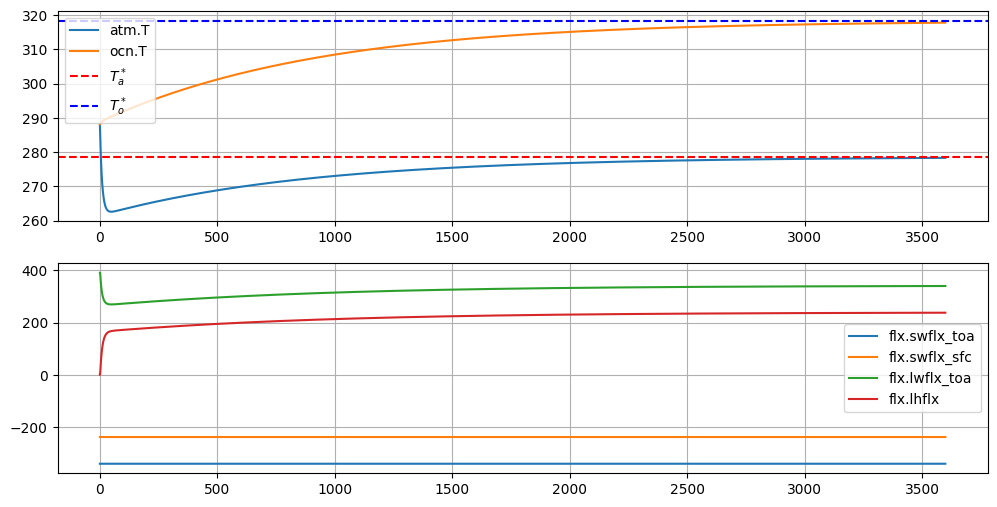

In [13]:
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms

def simple_moving_average(data, window_size):
    weights = np.ones(window_size) / window_size
    sma = np.convolve(data, weights, mode='same')
    return sma

plot_names = [
    ("atm.T", "ocn.T",),
    ("flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa", "flx.lhflx",),
]

N_plot_names = len(plot_names)

fig, ax = plt.subplots(N_plot_names, 1, figsize=(12, 3*N_plot_names))
smooth_window_half_size = 0
smooth_window = smooth_window_half_size * 2 + 1

for i, full_varnames in enumerate(plot_names):
    _ax = ax[i]
    for j, full_varname in enumerate(full_varnames):
        y = recorder[full_varname]
        y_smooth = simple_moving_average(y, smooth_window)
        y_smooth[:smooth_window_half_size] = np.nan
        y_smooth[len(y)-smooth_window_half_size:] = np.nan
        _ax.plot(range(len(y)), y_smooth, label=full_varname)
        
    if i == 0:
        trans = transforms.blended_transform_factory(_ax.transAxes, _ax.transData)
        _ax.plot([0, 1], [T_a, T_a], color="red", linestyle="dashed", transform=trans, label="$T^*_a$")
        _ax.plot([0, 1], [T_o, T_o], color="blue", linestyle="dashed", transform=trans, label="$T^*_o$")

    _ax.legend()
    _ax.grid()


plt.show()